In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

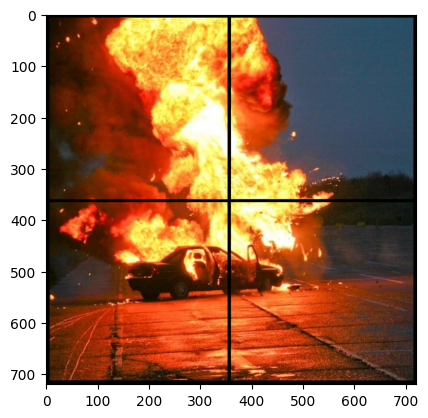

In [3]:
meledak_bgr = cv.imread('Assets/Meledak.PNG')
meledak = cv.cvtColor(meledak_bgr, cv.COLOR_BGR2RGB)
plt.imshow(meledak)
plt.show()

Text(0.5, 1.0, 'Citra potongan 4')

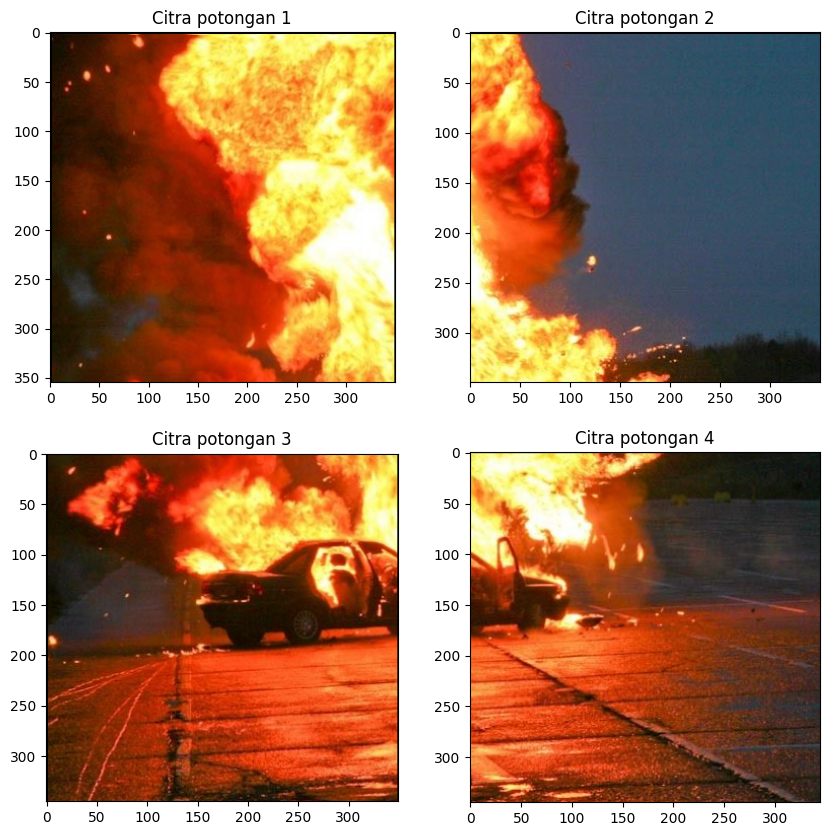

In [4]:
def fungsi_potong(gambar, a, b, mode='H'): 
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

potong_1_sementara = fungsi_potong(meledak, 5, 360)
potong_1 = fungsi_potong(potong_1_sementara, 5, 355, mode='V')
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1); plt.imshow(potong_1, cmap="gray"); plt.title('Citra potongan 1')


potong_2_sementara = fungsi_potong(meledak, 5, 355, mode='H')
potong_2 = fungsi_potong(potong_2_sementara, 360, 710, mode='V')
plt.subplot(2, 2, 2); plt.imshow(potong_2, cmap="gray"); plt.title('Citra potongan 2')

potong_3_sementara = fungsi_potong(meledak, 365, 710, mode='H')
potong_3 = fungsi_potong(potong_3_sementara, 5, 355, mode='V')
plt.subplot(2, 2, 3); plt.imshow(potong_3, cmap="gray"); plt.title('Citra potongan 3')

potong_4_sementara = fungsi_potong(meledak, 365, 710)
potong_4 = fungsi_potong(potong_4_sementara, 365, 710, mode='V')
plt.subplot(2, 2, 4); plt.imshow(potong_4, cmap="gray"); plt.title('Citra potongan 4')



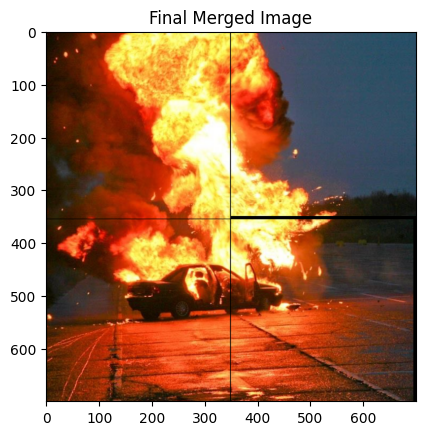

In [7]:
def merge_image(image1, image2, orientation='H'):
    if orientation == 'H':
        height = max(image1.shape[0], image2.shape[0])
        total_width = image1.shape[1] + image2.shape[1]
        if len(image1.shape) == 2:
            merged = np.zeros((height, total_width), dtype=image1.dtype)
        else:
            merged = np.zeros((height, total_width, image1.shape[2]), dtype=image1.dtype)
        merged[0:image1.shape[0], 0:image1.shape[1]] = image1
        merged[0:image2.shape[0], image1.shape[1]:image1.shape[1]+image2.shape[1]] = image2
    else:
        total_height = image1.shape[0] + image2.shape[0]
        width = max(image1.shape[1], image2.shape[1])
        if len(image1.shape) == 2:
            merged = np.zeros((total_height, width), dtype=image1.dtype)
        else:
            merged = np.zeros((total_height, width, image1.shape[2]), dtype=image1.dtype)
        merged[0:image1.shape[0], 0:image1.shape[1]] = image1
        merged[image1.shape[0]:image1.shape[0]+image2.shape[0], 0:image2.shape[1]] = image2
    return merged

merge_image(potong_1, potong_2, orientation='H')
merge_image(potong_3, potong_4, orientation='H')
final_image = merge_image(merge_image(potong_1, potong_2, orientation='H'), merge_image(potong_3, potong_4, orientation='H'), orientation='V')
plt.imshow(final_image)
plt.title('Final Merged Image')
plt.show()



Text(0.5, 1.0, 'Kembang')

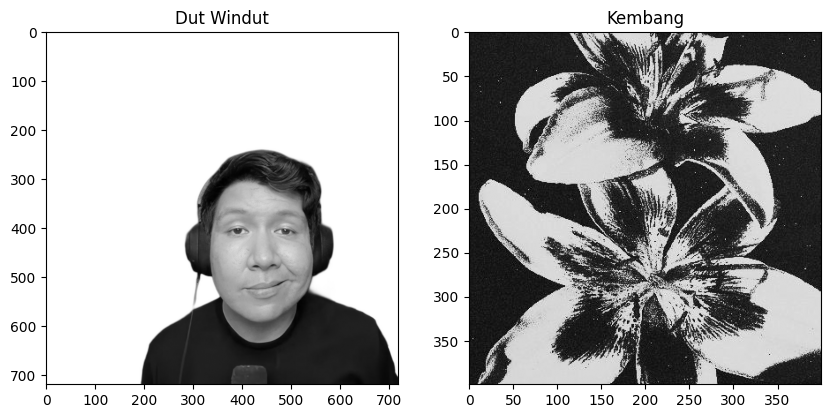

In [8]:
dutwindut = cv.imread('Assets/Windut.PNG', cv.IMREAD_GRAYSCALE)
kembang = cv.imread('Assets/Bunga.PNG', cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(dutwindut, cmap='gray')
plt.title('Dut Windut')

plt.subplot(1, 2, 2)
plt.imshow(kembang, cmap='gray')
plt.title('Kembang')


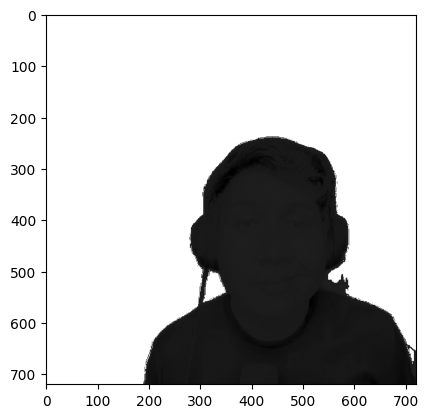

In [11]:
def histogram_specification(source_image, target_image):
    hist_source = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    for i in range(source_image.shape[0]):
        for j in range(source_image.shape[1]):
            hist_source[int(source_image[i, j])] += 1

    for i in range(target_image.shape[0]):
        for j in range(target_image.shape[1]):
            hist_target[int(target_image[i, j])] += 1

    cdf_source = np.cumsum(hist_source).astype(float)
    cdf_target = np.cumsum(hist_target).astype(float)

    cdf_source /= cdf_source[-1]
    cdf_target /= cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)
    j = 0
    for i in range(256):
        while j < 255 and cdf_target[j] < cdf_source[i]:
            j += 1
        map_hist[i] = j

    result = np.zeros(source_image.shape, dtype=np.uint8)
    for i in range(source_image.shape[0]):
        for j in range(source_image.shape[1]):
            result[i, j] = map_hist[int(source_image[i, j])]

    return result

windut_ireng = histogram_specification(dutwindut, kembang)
plt.imshow(windut_ireng, cmap='gray')
plt.show()


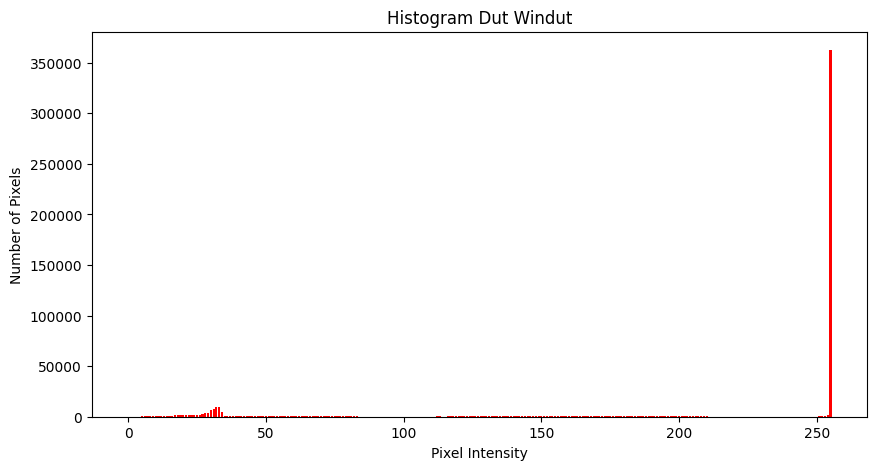

In [10]:
def make_hist(image):
    histogram = [0] * 256
    
    height = len(image)
    width = len(image[0]) if height > 0 else 0
    for i in range(height):
        for j in range(width):
            val = int(image[i][j])
            histogram[val] += 1
    return histogram

def plot_histogram(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5))
    plt.xlabel("Pixel Intensity")
    plt.title(title)
    plt.ylabel("Number of Pixels")
    plt.bar(range(256), histogram, color=ImgColor, width=0.8)
    plt.show()
    
plot_histogram(make_hist(dutwindut), "Histogram Dut Windut", "red")

In [12]:
def fungsi_gabung(citra_1, citra_2):
    return citra_1 + citra_2

gabung_citra = fungsi_gabung(final_image, windut_ireng)
plt.subplot(1, 1, 1); plt.imshow(gabung_citra, cmap="gray"); plt.title('Merge Citra')

ValueError: operands could not be broadcast together with shapes (700,700,3) (720,720) 